# Desk synthesis — Empirical MM (multi-lens board)

**Program status (2026-09-30): Holds pass COMPLETE** on public HL tape.

SoT: [`../DESK_MEMO.md`](../DESK_MEMO.md) · [`../CHAPTER_INDEX.md`](../CHAPTER_INDEX.md) · [`../docs/COVERAGE.md`](../docs/COVERAGE.md).

This notebook embeds key figures from **ch13–18, 22, 15, 16** (plus decision rollup). No ClickHouse MCP.


## Promote by lens (static snapshot)

| Lens | Promotes |
|------|----------|
| **mm** | spread, resilience, refill, touch, LOB intensity/ac1, Parlour, sign ACF, OFI, markout, HS π, AR σ_w, VPIN |
| **disc** | sign ACF, λ, IRF, MRR θ, GH, HS π, MA1/AR σ_w, Parlour, LOB ac1, jump concord, Sandas L1, qty ceiling |
| **cont** | OFI, VPIN, intensity, IS, Epps, touch, size-touch, cancel proxy, refill, LOB intensity, resilience |
| **exec** | λ, IRF, GH, intensity, touch, LOB intensity, Parlour, IS, Epps, Amihud, markout, VPIN, spread |
| **info** | markout, OFI, λ, IRF, MRR, GH, HS π, MA1/AR σ_w, VPIN, intensity, IS, Epps, jumps, Amihud, sign ACF |
| **liq** | spread, Amihud, MRR θ, HS π, refill, resilience, Sandas L1, qty ceiling |

**Promote:** PIN MLE (28 usable days, PIN̂≈0.183). **Hold:** PIN proxy, HS α|β (â<0), OE fill hazard, Part III theory.\*, `mrr_rho_q`, `volclock_ac1`.

**Kill:** Roll\*, `info.improve_markout`, `cont.noise_rv_ratio` (boot CI≈[0.87,0.91]).


## Decision rollup (all `out/*/exp_*_summary.json`)


In [1]:
from pathlib import Path
import json
import pandas as pd
OUT = Path('..') / 'out'
rows = []
for p in sorted(OUT.glob('*/exp_*_summary.json')):
    d = json.loads(p.read_text())
    for k, v in d.get('decisions', {}).items():
        lenses = d.get('lenses', {}).get(k) or []
        rows.append({'pkg': p.parent.name, 'id': k, 'decision': v, 'lenses': ','.join(lenses)})
df = pd.DataFrame(rows)
print('Promote', int((df.decision=='Promote').sum()), '/ total', len(df))
print('Kill', int((df.decision=='Kill').sum()), 'Hold', int((df.decision=='Hold').sum()))
display(df[df.decision=='Promote'].sort_values(['pkg','id']))
display(df[df.decision!='Promote'].sort_values(['decision','pkg','id']))
lens_rows = []
for _, r in df[df.decision=='Promote'].iterrows():
    for L in (r.lenses.split(',') if r.lenses else []):
        if L: lens_rows.append({'lens': L, 'id': r.id})
if lens_rows:
    display(pd.DataFrame(lens_rows).groupby('lens').size().rename('n').sort_values(ascending=False).to_frame())


Promote 31 / total 51
Kill 5 Hold 15


## ETH snapshot levels (from ch16 board / sibling summaries)

| Metric | Level | Status |
|--------|------:|--------|
| Quote-aligned λ (OLS) | ≈0.199 | Promote |
| Permanent IRF | ≈0.422 | Promote |
| Markout 1s (bps) | ≈0.472 | Promote |
| Sign ρ₁ | ≈0.535 | Promote |
| MRR θ | ≈0.048 | Promote |
| GH z₀ | ≈0.189 | Promote |
| HS lump π / two-way λ̂ | ≈0.010 / ≈0.39 | Promote |
| HS â (AS three-way) | ≈−0.18 | **Hold** |
| PIN MLE (28 days) | ≈0.183 | **Promote** |
| VPIN mean | ≈0.905 | Promote |
| Quoted spread (bps) | ≈0.382 | Promote |
| AR(10) σ_w | ≈5.1e-5 | Promote |
| Noise RV ratio | ≈0.87 | **Kill** |
| IS HL∈[low,high] | ≈[0.34, 0.97] | Promote |
| Epps corr @60s | ≈0.94 | Promote |



## Key figure board (ch13–18, 22, 15, 16)

Paths are relative to `../out/<pkg>/`. Re-run cells after regenerating plots.


### Impact / IRF (ch13)

Permanent mid IRF after signed trade — Promote `disc.irf_permanent`.

`out/ch13_var_impact/fig_irf_cum.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch13_var_impact/fig_irf_cum.png exists True bytes 62635


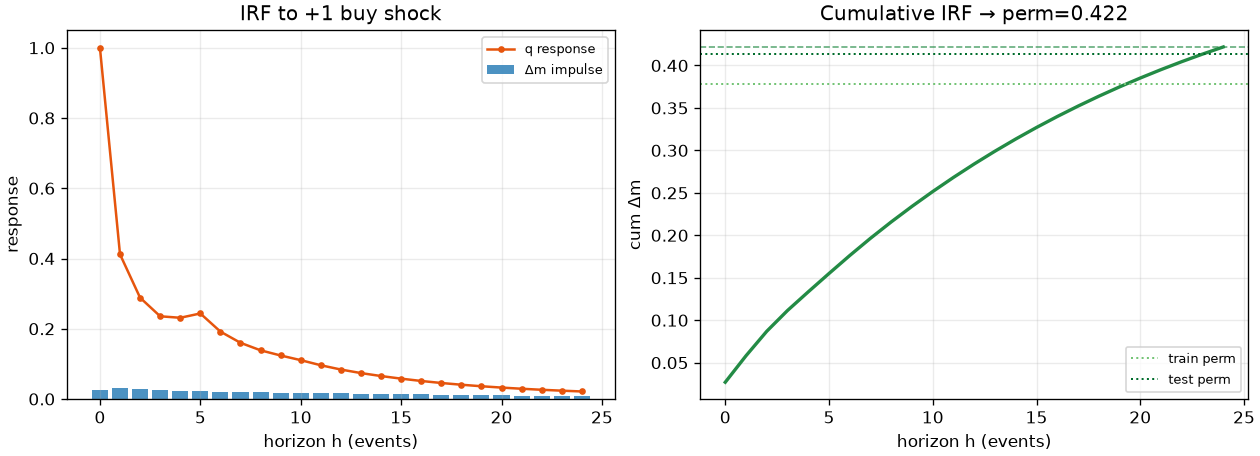

In [2]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch13_var_impact' / 'fig_irf_cum.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Markout 1s (ch13)

Maker adverse-selection / taker edge decay — Promote `info.markout_1s`.

`out/ch13_var_impact/fig_markout.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch13_var_impact/fig_markout.png exists True bytes 23090


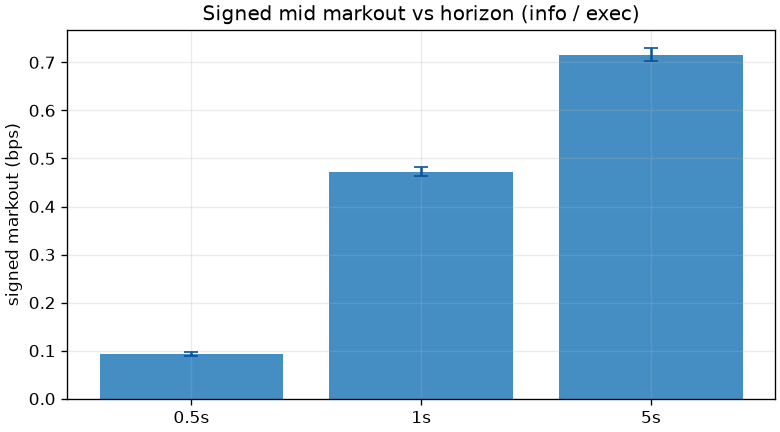

In [3]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch13_var_impact' / 'fig_markout.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### OFI ↔ mid (ch13)

Continuous flow ↔ return — Promote `cont.ofi_mid_corr`.

`out/ch13_var_impact/fig_ofi_scatter.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch13_var_impact/fig_ofi_scatter.png exists True bytes 102144


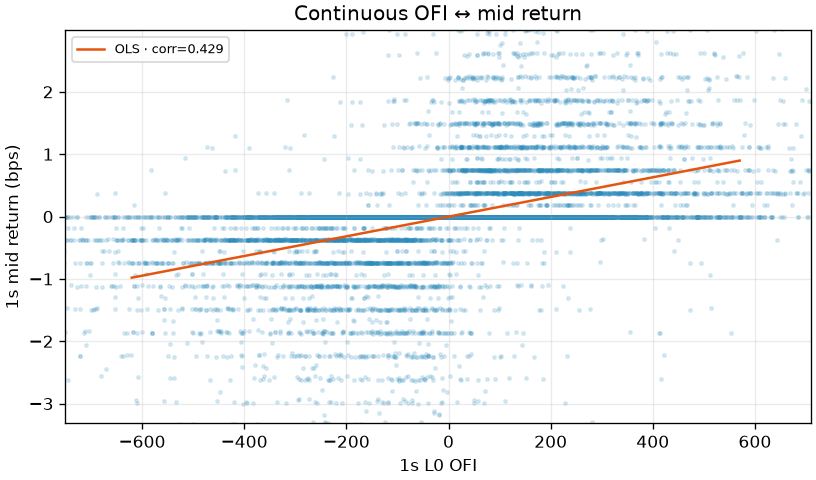

In [4]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch13_var_impact' / 'fig_ofi_scatter.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### HS / MRR / GH (ch14)

Structural permanent-impact family — Promote π / θ / z0; Hold α|β.

`out/ch14_structural/fig_perm_impact_compare.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch14_structural/fig_perm_impact_compare.png exists True bytes 46866


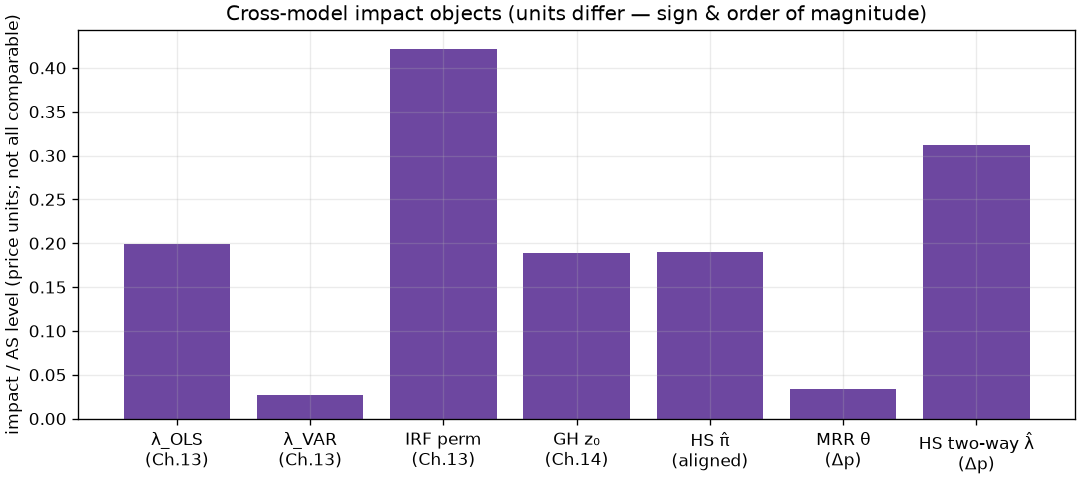

In [5]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch14_structural' / 'fig_perm_impact_compare.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### HS decomp (ch14)

Lump π Promote; three-way AS share Hold when â<0.

`out/ch14_structural/fig_hs_decomp.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch14_structural/fig_hs_decomp.png exists True bytes 41685


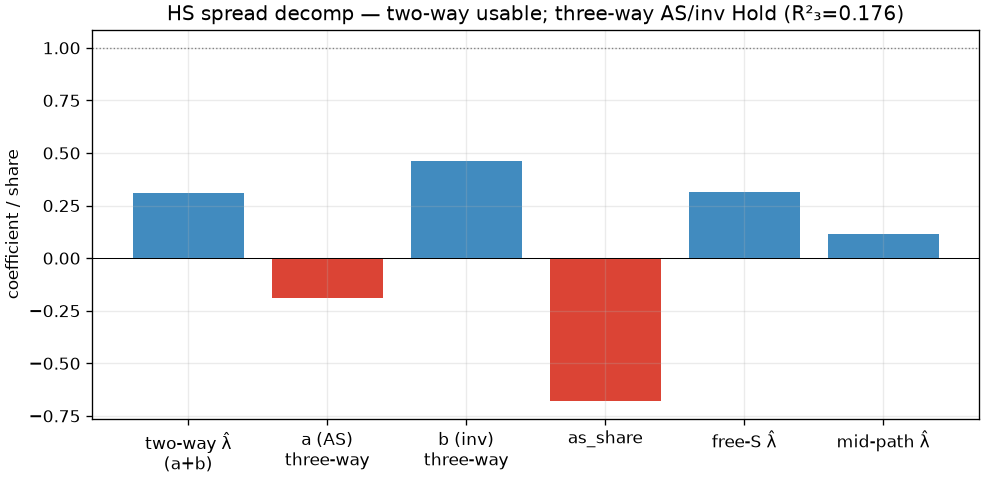

In [6]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch14_structural' / 'fig_hs_decomp.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### VPIN path (ch15)

Volume-clock toxicity — Promote `cont.vpin` (~0.90).

`out/ch15_pin/fig_vpin_path.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch15_pin/fig_vpin_path.png exists True bytes 99247


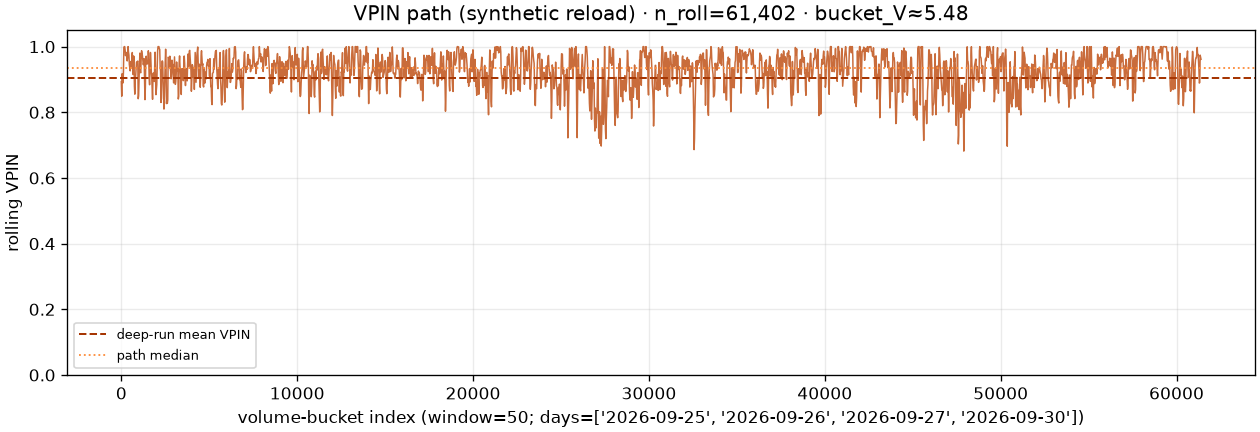

In [7]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch15_pin' / 'fig_vpin_path.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### PIN vs VPIN (ch15)

Different clocks — PIN Promote (28d); still do not swap PIN↔VPIN levels.

`out/ch15_pin/fig_pin_vs_vpin.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch15_pin/fig_pin_vs_vpin.png exists True bytes 32009


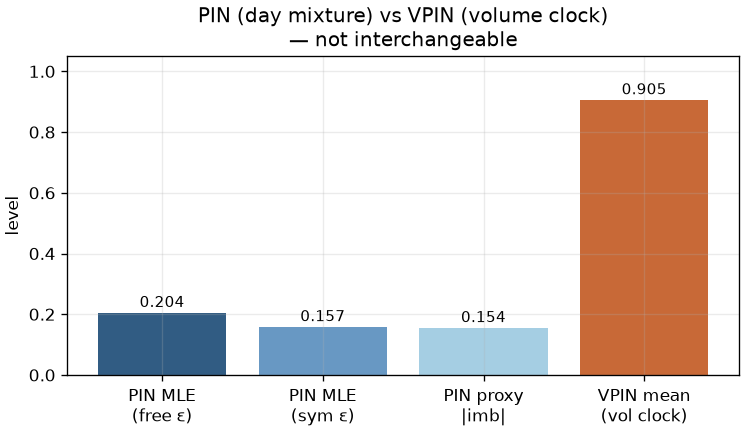

In [8]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch15_pin' / 'fig_pin_vs_vpin.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Measure board (ch16)

Cross-chapter asymmetry board — when PIN / impact / HS disagree.

`out/ch16_asymmetry/fig_measure_board.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch16_asymmetry/fig_measure_board.png exists True bytes 56414


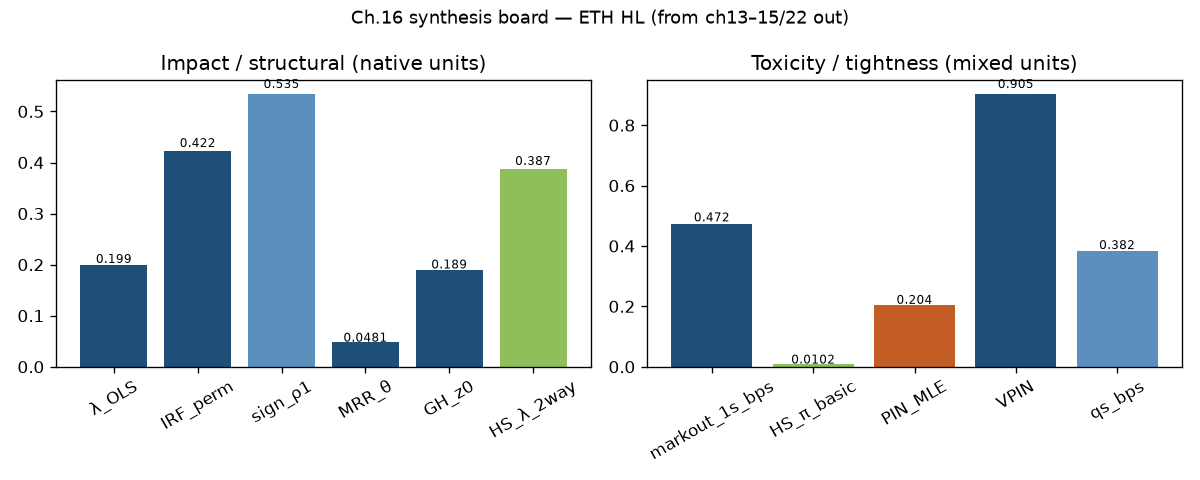

In [9]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch16_asymmetry' / 'fig_measure_board.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Status map (ch16)

Promote vs Hold map for desk asymmetry proxies.

`out/ch16_asymmetry/fig_status_map.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch16_asymmetry/fig_status_map.png exists True bytes 45676


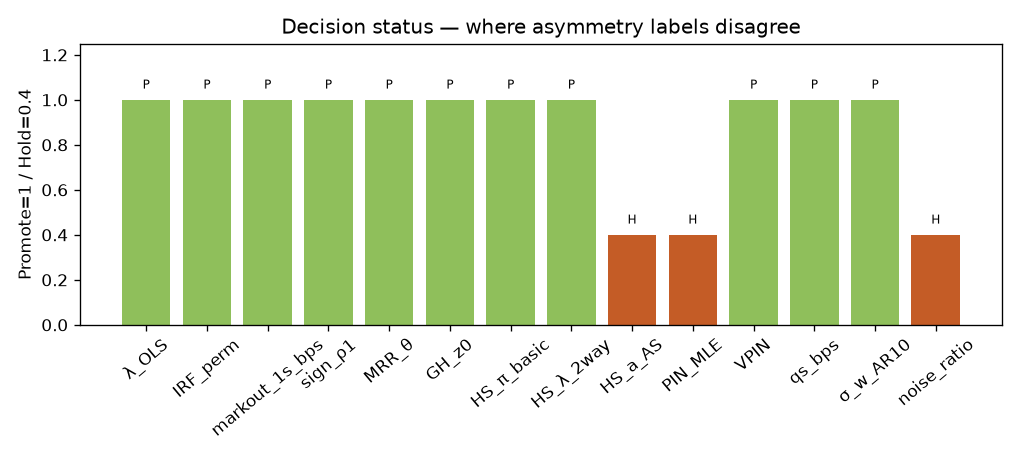

In [10]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch16_asymmetry' / 'fig_status_map.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Info shares (ch17)

HL vs Lit discovery weights — Promote `cont.info_share_hl_lit`.

`out/ch17_discovery/fig_info_share_bounds.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch17_discovery/fig_info_share_bounds.png exists True bytes 22343


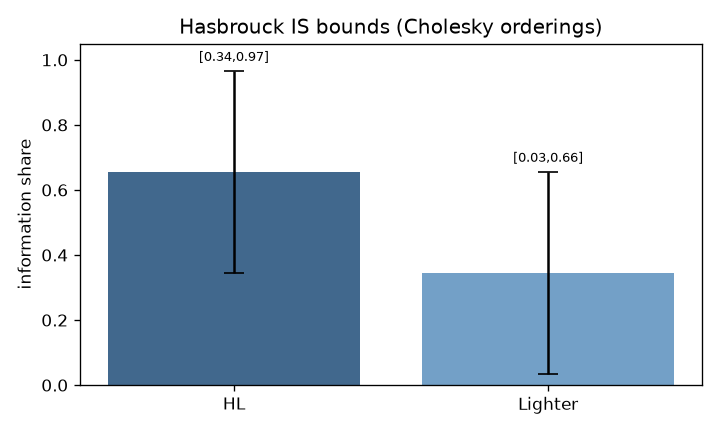

In [11]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch17_discovery' / 'fig_info_share_bounds.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Epps curve (ch17)

Sync horizon for x-venue corr — Promote `cont.epps_xvenue`.

`out/ch17_discovery/fig_epps_curve.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch17_discovery/fig_epps_curve.png exists True bytes 37028


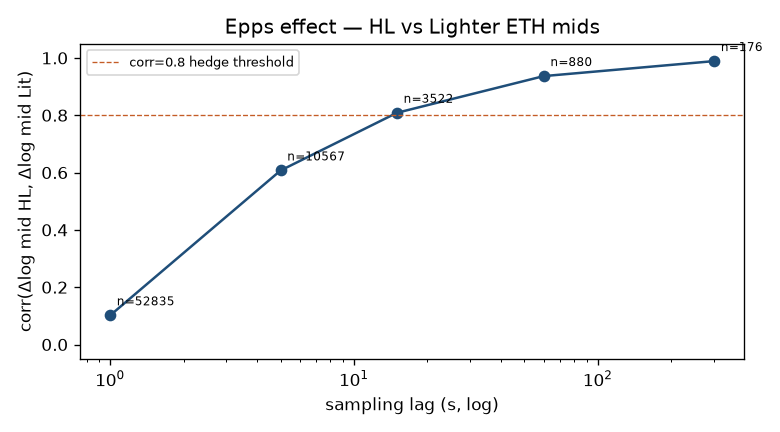

In [12]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch17_discovery' / 'fig_epps_curve.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Time-to-touch (ch18)

Public fill-proxy vs tick offset — Promote `cont.time_to_touch`.

`out/ch18_limit_orders/fig_time_to_touch.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch18_limit_orders/fig_time_to_touch.png exists True bytes 51460


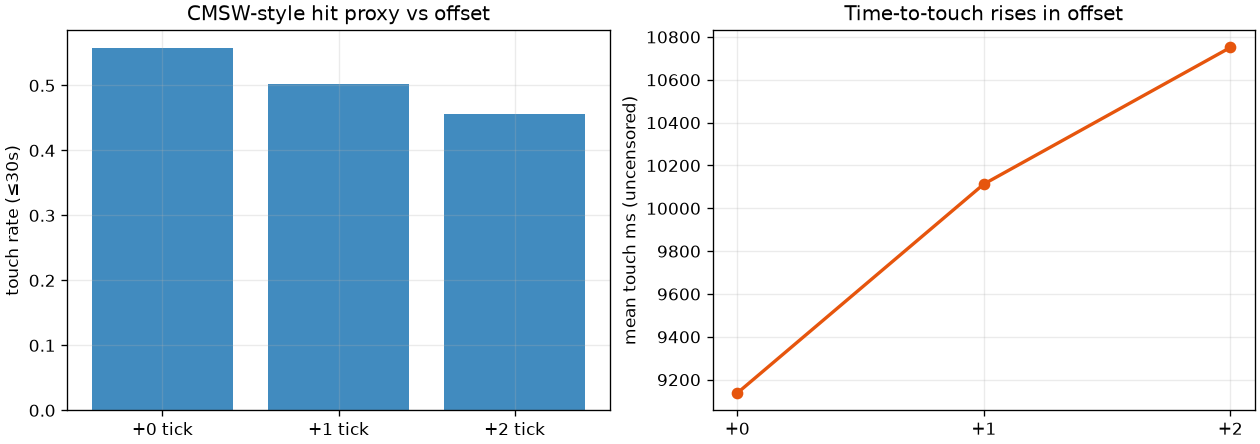

In [13]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch18_limit_orders' / 'fig_time_to_touch.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Sandas L1 (ch18)

Behind-touch depth schedule — Promote `disc.sandas_depth_moments`.

`out/ch18_limit_orders/fig_sandas_depth.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch18_limit_orders/fig_sandas_depth.png exists True bytes 76206


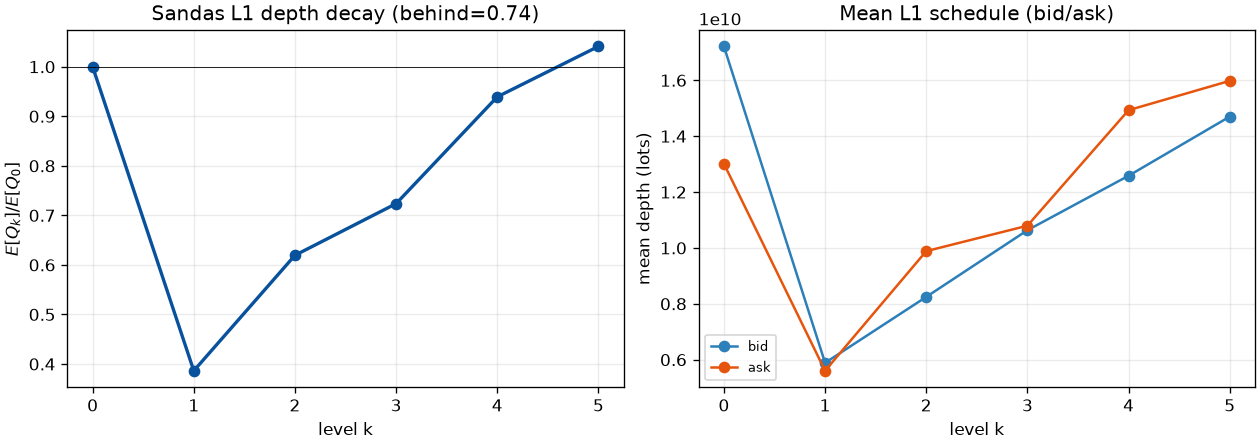

In [14]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch18_limit_orders' / 'fig_sandas_depth.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Resilience (ch18)

L0 refill after trade — Promote resilience / same-side refill.

`out/ch18_limit_orders/fig_resilience_refill.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch18_limit_orders/fig_resilience_refill.png exists True bytes 59003


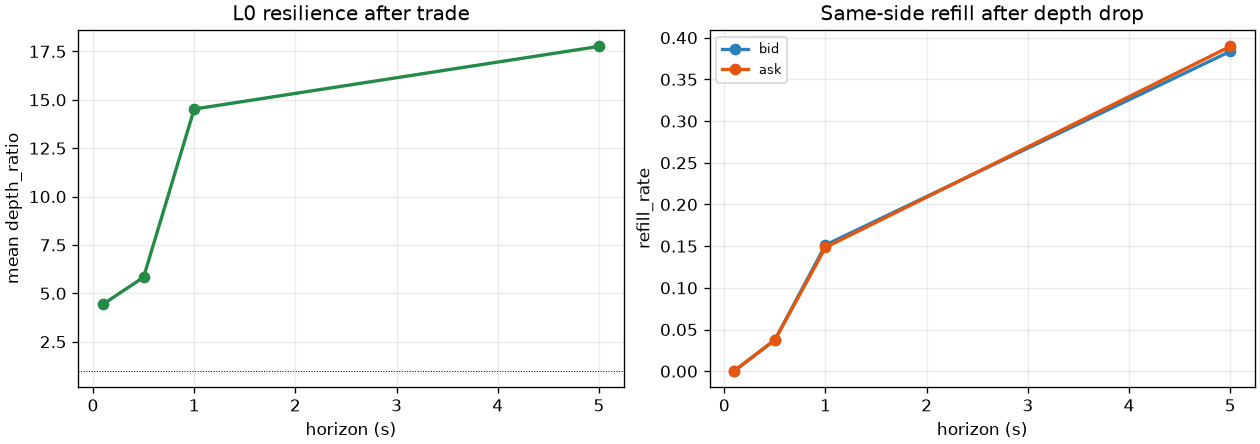

In [15]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch18_limit_orders' / 'fig_resilience_refill.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Quoted spread (ch22)

Cost floor — Promote `liq.quoted_spread_bps` (~0.38 bps).

`out/ch22_liquidity/fig_quoted_spread.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch22_liquidity/fig_quoted_spread.png exists True bytes 38498


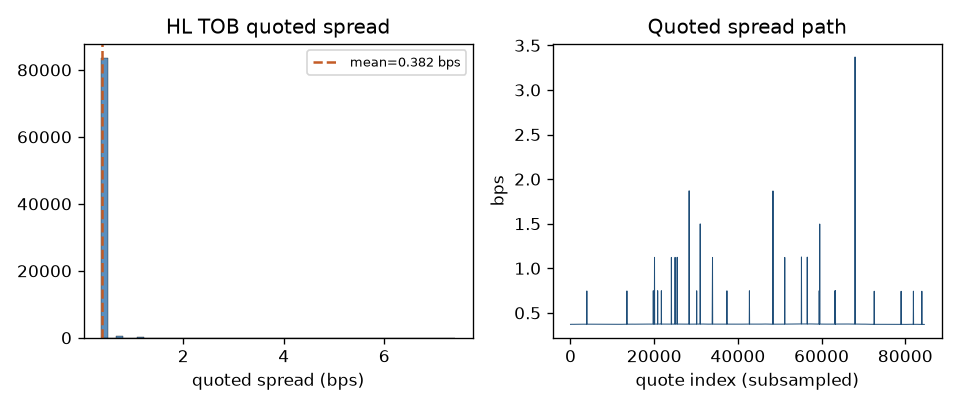

In [16]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch22_liquidity' / 'fig_quoted_spread.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


### Amihud (ch22)

ILLIQ state variable — Promote `liq.amihud_1m`.

`out/ch22_liquidity/fig_amihud_ts.png`


${ARES_MICROSTRUCTURE:-$HOME/srv/ares-microstructure}/research/books/empirical_mm/out/ch22_liquidity/fig_amihud_ts.png exists True bytes 54544


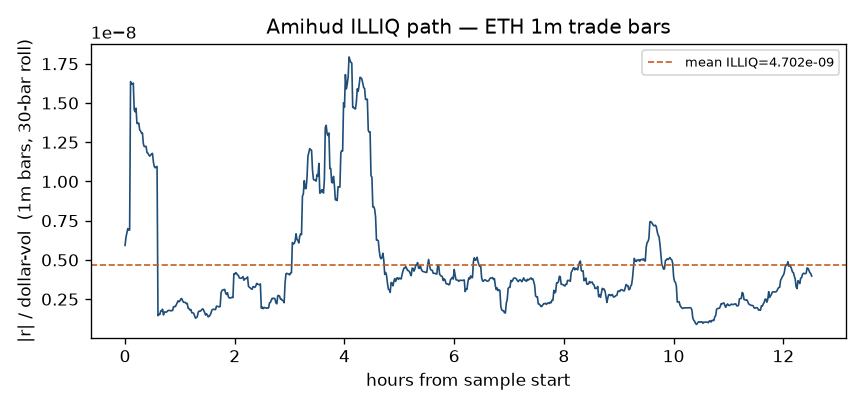

In [17]:
from IPython.display import Image, display
from pathlib import Path
p = Path('..') / 'out' / 'ch22_liquidity' / 'fig_amihud_ts.png'
print(p.resolve(), 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('MISSING — regenerate via scripts/plot_*.py')


## Remaining Holds (ceiling — not unfinished scripts)

1. **PIN MLE** — need ≥20 usable full days (preferred-shard tails; currently 14).
2. **HS α|β** — unconstrained â<0; needs inventory analogue / constrained GMM.
3. **OE fill hazard + Part III structural theory** — not on public tape (dry_gateway/SHM only); use size-touch / cancel proxies instead.
4. **`mrr_rho_q` / `volclock_ac1`** — weak / not standalone tradable.

Public multilevel L2 for L1 Sandas moments is **shipped**. Identifiable public-tape empirics are **complete**.
